In [13]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import json

# Import functions from accuracy_analyzer
from accuracy_analyzer import analyze_accuracy

# Define the missing function locally
def analyze_multiple_thresholds(file_path, thresholds):
    """
    Analyze accuracy across multiple thresholds.
    
    Args:
        file_path (str): Path to the JSONL file
        thresholds (list): List of thresholds to test
        
    Returns:
        list: List of results dictionaries
    """
    results = []
    for threshold in thresholds:
        result = analyze_accuracy(file_path, threshold)
        results.append(result)
    return results

# Set up matplotlib for notebook
%matplotlib inline
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")


Libraries imported successfully!


In [14]:
# File paths - update these to match your files
nlp4opt_file = "datasets/nlp4opt/experiment_results_20250630_005435.jsonl"
nlp4lp_file = "datasets/nlp4lp/experiment_results_20250630_123639.jsonl"

# Check if files exist
files_to_analyze = []
if Path(nlp4opt_file).exists():
    files_to_analyze.append((nlp4opt_file, "NLP4OPT"))
    print(f"✓ Found: {nlp4opt_file}")
else:
    print(f"✗ Not found: {nlp4opt_file}")

if Path(nlp4lp_file).exists():
    files_to_analyze.append((nlp4lp_file, "NLP4LP"))
    print(f"✓ Found: {nlp4lp_file}")
else:
    print(f"✗ Not found: {nlp4lp_file}")

print(f"\nWill analyze {len(files_to_analyze)} file(s)")


✓ Found: datasets/nlp4opt/experiment_results_20250630_005435.jsonl
✓ Found: datasets/nlp4lp/experiment_results_20250630_123639.jsonl

Will analyze 2 file(s)


In [15]:
# Define thresholds to test
thresholds = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

# Analyze multiple thresholds for each file
all_results = {}

for file_path, dataset_name in files_to_analyze:
    print(f"Analyzing {dataset_name} across {len(thresholds)} thresholds...")
    results = analyze_multiple_thresholds(file_path, thresholds)
    all_results[dataset_name] = results
    
    # Print summary table
    print(f"\n{dataset_name} - Threshold vs Accuracy:")
    print("-" * 50)
    print(f"{'Threshold':<12} {'Accuracy':<10} {'Correct':<8} {'Total':<8}")
    print("-" * 50)
    for result in results:
        print(f"{result['threshold']:<12} {result['accuracy_percentage']:<10.2f}% "
              f"{result['correct_predictions']:<8} {result['total_problems']:<8}")

print("\nMulti-threshold analysis complete!")


Analyzing NLP4OPT across 7 thresholds...

NLP4OPT - Threshold vs Accuracy:
--------------------------------------------------
Threshold    Accuracy   Correct  Total   
--------------------------------------------------
1e-06        69.74     % 159      228     
1e-05        69.74     % 159      228     
0.0001       69.74     % 159      228     
0.001        70.18     % 160      228     
0.01         71.49     % 163      228     
0.1          71.49     % 163      228     
1.0          75.00     % 171      228     
Analyzing NLP4LP across 7 thresholds...

NLP4LP - Threshold vs Accuracy:
--------------------------------------------------
Threshold    Accuracy   Correct  Total   
--------------------------------------------------
1e-06        71.37     % 172      241     
1e-05        71.37     % 172      241     
0.0001       71.37     % 172      241     
0.001        71.37     % 172      241     
0.01         74.27     % 179      241     
0.1          74.27     % 179      241     
1.0  

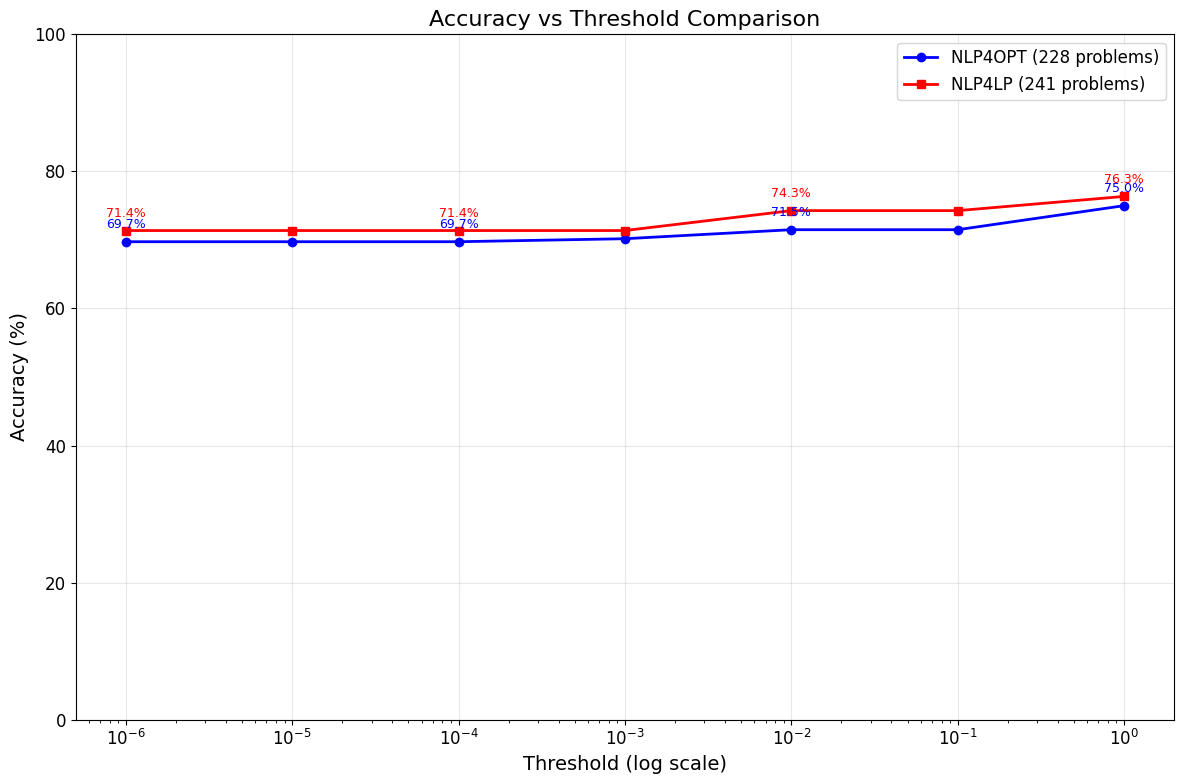

In [16]:
def plot_accuracy_vs_threshold(all_results):
    """Plot accuracy vs threshold for all datasets."""
    plt.figure(figsize=(12, 8))
    
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    markers = ['o', 's', '^', 'D', 'v']
    
    for i, (dataset_name, results) in enumerate(all_results.items()):
        # Ensure data is in proper format for plotting
        thresholds = np.array([float(r['threshold']) for r in results])
        accuracies = np.array([float(r['accuracy']) * 100 for r in results])
        
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        
        # Use separate color and marker parameters
        plt.semilogx(thresholds, accuracies, color=color, marker=marker, 
                    linestyle='-', linewidth=2, markersize=6, 
                    label=f'{dataset_name} ({results[0]["total_problems"]} problems)')
        
        # Add annotations for key points
        for j, (thresh, acc) in enumerate(zip(thresholds, accuracies)):
            if j % max(1, len(thresholds)//3) == 0:  # Annotate every 3rd point
                plt.annotate(f'{acc:.1f}%', (float(thresh), float(acc)), 
                           textcoords="offset points", xytext=(0,10), ha='center',
                           fontsize=9, color=color)
    
    plt.xlabel('Threshold (log scale)', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.title('Accuracy vs Threshold Comparison', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

# Create the plot
if all_results:
    plot_accuracy_vs_threshold(all_results)
else:
    print("No results to plot. Please run the multi-threshold analysis first.")



Error distribution for NLP4OPT:


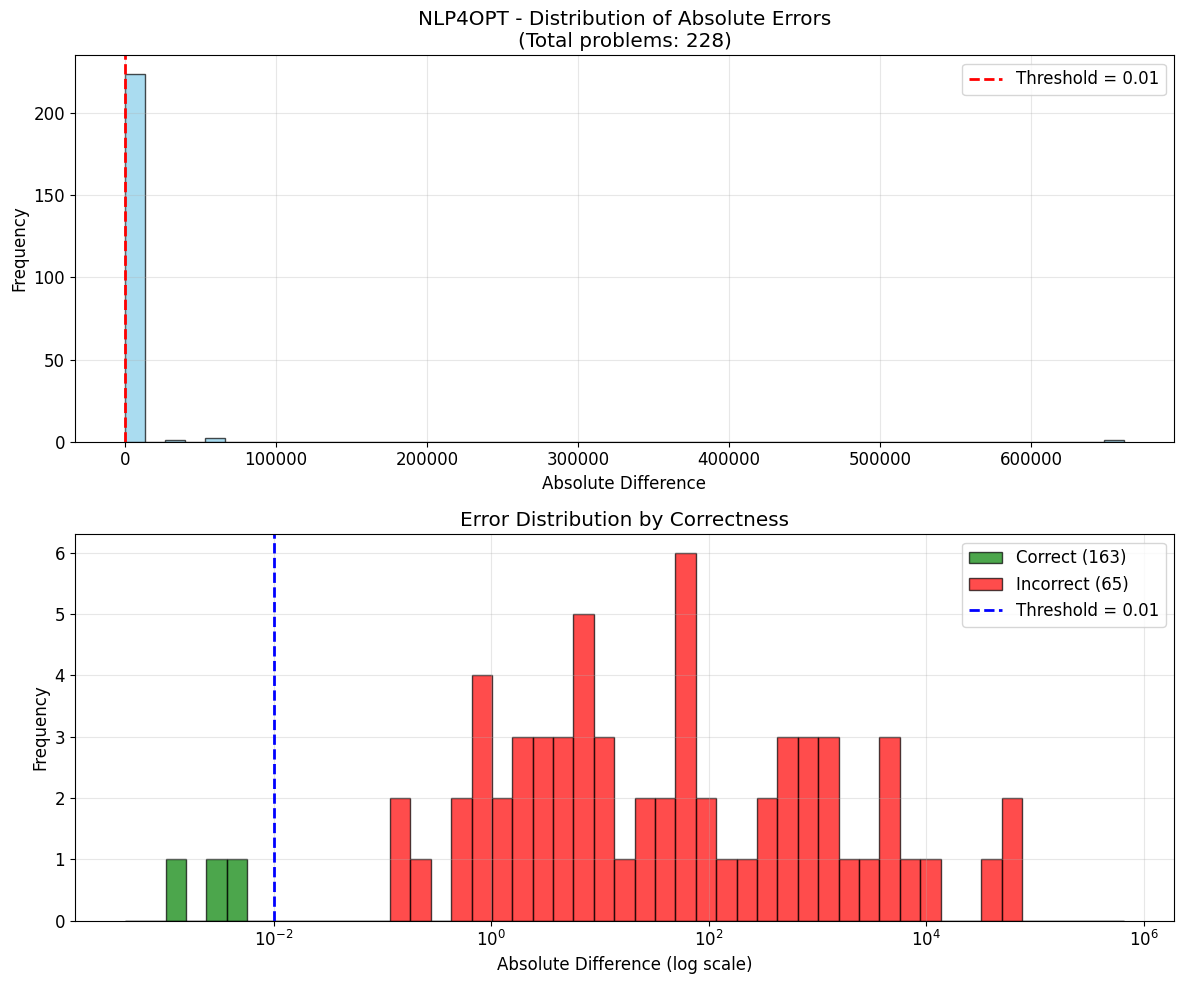


Error distribution for NLP4LP:


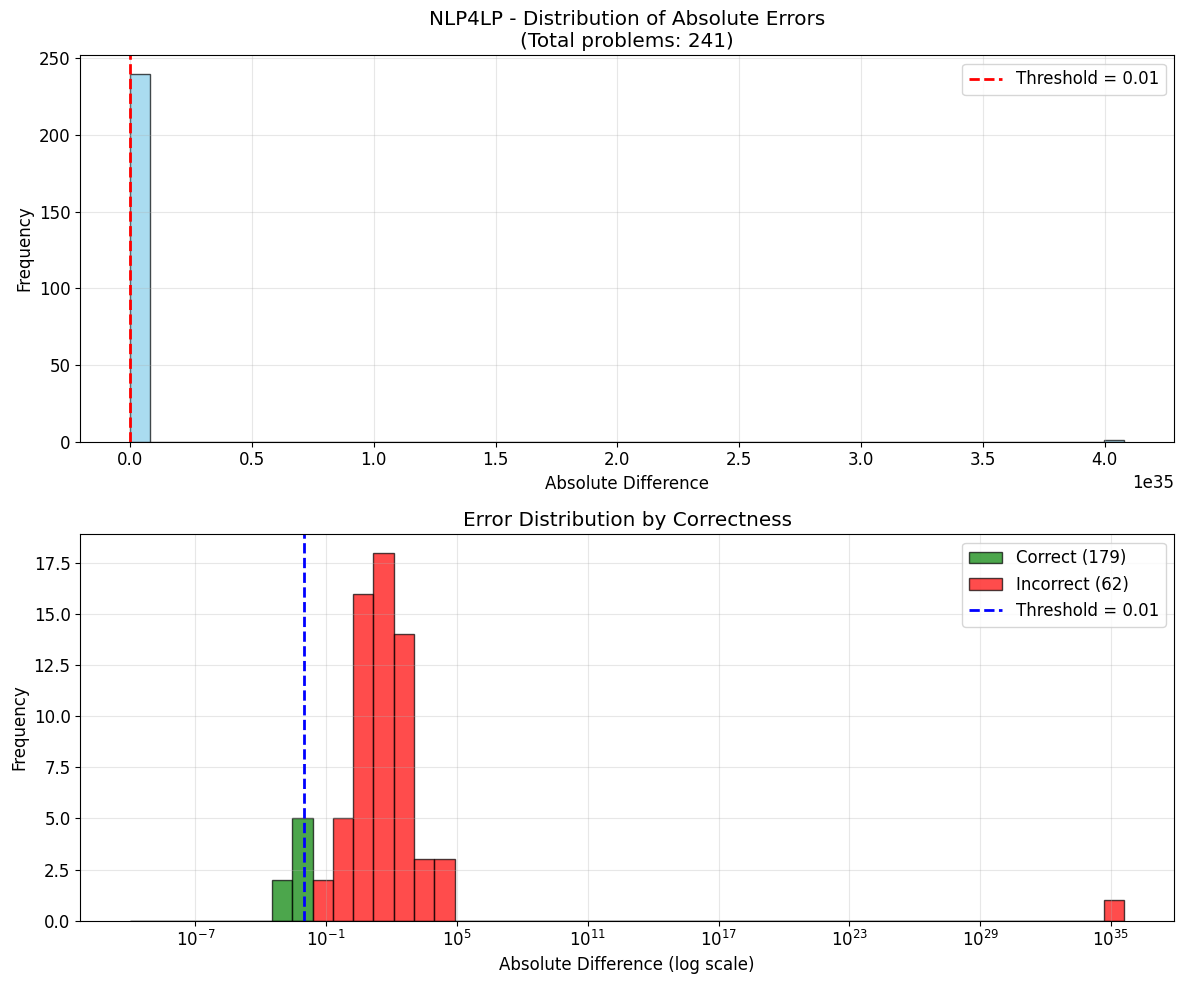

In [17]:
def plot_error_distribution(dataset_name, results, threshold_idx=4):  # Use 1e-4 by default
    """Plot distribution of absolute errors."""
    result = results[threshold_idx]  # Use specified threshold index
    
    # Ensure data is in proper format for plotting
    abs_diffs = np.array([float(r['absolute_difference']) for r in result['detailed_results']])
    correct_flags = [bool(r['is_correct']) for r in result['detailed_results']]
    
    correct_diffs = np.array([d for d, c in zip(abs_diffs, correct_flags) if c])
    incorrect_diffs = np.array([d for d, c in zip(abs_diffs, correct_flags) if not c])
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Overall distribution
    ax1.hist(abs_diffs, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(float(result['threshold']), color='red', linestyle='--', linewidth=2, 
                label=f'Threshold = {result["threshold"]}')
    ax1.set_xlabel('Absolute Difference')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'{dataset_name} - Distribution of Absolute Errors\n(Total problems: {result["total_problems"]})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Separate distributions for correct/incorrect (log scale)
    if len(abs_diffs) > 0:
        # Filter out zero values for log scale
        nonzero_diffs = abs_diffs[abs_diffs > 0]
        if len(nonzero_diffs) > 0:
            min_diff = max(1e-10, float(np.min(nonzero_diffs)))
            max_diff = float(np.max(abs_diffs))
            bins = np.logspace(np.log10(min_diff), np.log10(max_diff), 50)
            
            if len(correct_diffs) > 0:
                correct_nonzero = correct_diffs[correct_diffs > 0]
                if len(correct_nonzero) > 0:
                    ax2.hist(correct_nonzero, bins=bins, alpha=0.7, color='green', 
                             label=f'Correct ({len(correct_diffs)})', edgecolor='black')
            
            if len(incorrect_diffs) > 0:
                incorrect_nonzero = incorrect_diffs[incorrect_diffs > 0]
                if len(incorrect_nonzero) > 0:
                    ax2.hist(incorrect_nonzero, bins=bins, alpha=0.7, color='red',
                             label=f'Incorrect ({len(incorrect_diffs)})', edgecolor='black')
            
            ax2.axvline(float(result['threshold']), color='blue', linestyle='--', linewidth=2,
                        label=f'Threshold = {result["threshold"]}')
            ax2.set_xscale('log')
            ax2.set_xlabel('Absolute Difference (log scale)')
            ax2.set_ylabel('Frequency')
            ax2.set_title('Error Distribution by Correctness')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create error distribution plots for each dataset
for dataset_name, results in all_results.items():
    print(f"\nError distribution for {dataset_name}:")
    plot_error_distribution(dataset_name, results)


In [18]:
# Import the updated ranking function
from accuracy_analyzer import rank_incorrect_samples

# Example: Analyze and rank incorrect samples for NLP4OPT dataset
# file_path = "datasets/nlp4lp/experiment_results_20250630_123639.jsonl"
file_path = "datasets/nlp4opt/experiment_results_20250630_005435.jsonl"
threshold = 1e-2

# Analyze accuracy
results = analyze_accuracy(file_path, threshold)

print(f"Analysis for: {file_path}")
print(f"Threshold: {threshold}")
print(f"Total problems: {results['total_problems']}")
print(f"Incorrect predictions: {results['incorrect_predictions']}")
print(f"Accuracy: {results['accuracy_percentage']:.2f}%")

print("\n" + "="*80)
print("ERROR PERCENTAGE RANKING DEMONSTRATIONS")
print("="*80)

# Demo 1: Rank by error percentage (ascending - best to worst)
print("\n1. BEST INCORRECT PREDICTIONS (ascending order - smallest error % first)")
ranked_by_error_asc = rank_incorrect_samples(results, ascending=True)
print(f"{'Rank':<5} {'Index':<6} {'Gold':<10} {'Predicted':<10} {'Abs Diff':<12} {'Error %':<10}")
print("-" * 80)
for rank, sample in enumerate(ranked_by_error_asc[:10], 1):
    print(f"{rank:<5} "
          f"{sample['index']:<6} "
          f"{sample['gold_answer']:<10.4f} "
          f"{sample['predicted_answer']:<10.4f} "
          f"{sample['absolute_difference']:<12.6f} "
          f"{sample['error_percentage']:<10.2f}%")

# Demo 2: Rank by error percentage (descending - worst to best)
print("\n2. WORST INCORRECT PREDICTIONS (descending order - largest error % first)")
ranked_by_error_desc = rank_incorrect_samples(results, ascending=False)
print(f"{'Rank':<5} {'Index':<6} {'Gold':<10} {'Predicted':<10} {'Abs Diff':<12} {'Error %':<10}")
print("-" * 80)
for rank, sample in enumerate(ranked_by_error_desc[:10], 1):
    print(f"{rank:<5} "
          f"{sample['index']:<6} "
          f"{sample['gold_answer']:<10.4f} "
          f"{sample['predicted_answer']:<10.4f} "
          f"{sample['absolute_difference']:<12.6f} "
          f"{sample['error_percentage']:<10.2f}%")

print(f"\nSUMMARY:")
print(f"Best error percentage: {ranked_by_error_asc[0]['error_percentage']:.2f}%")
print(f"Worst error percentage: {ranked_by_error_desc[0]['error_percentage']:.2f}%")
print(f"Total incorrect predictions analyzed: {len(ranked_by_error_asc)}")


Analysis for: datasets/nlp4opt/experiment_results_20250630_005435.jsonl
Threshold: 0.01
Total problems: 228
Incorrect predictions: 65
Accuracy: 71.49%

ERROR PERCENTAGE RANKING DEMONSTRATIONS

1. BEST INCORRECT PREDICTIONS (ascending order - smallest error % first)
Rank  Index  Gold       Predicted  Abs Diff     Error %   
--------------------------------------------------------------------------------
1     217    256500.0000 256551.7241 51.724138    0.02      %
2     139    10060.0000 10057.1429 2.857143     0.03      %
3     101    342750.0000 342857.1400 107.140000   0.03      %
4     31     233.5000   233.3300   0.170000     0.07      %
5     84     1001.0000  1000.0000  1.000000     0.10      %
6     102    29950.0000 30000.0000 50.000000    0.17      %
7     125    11980.0000 12000.0000 20.000000    0.17      %
8     195    110.0000   109.7700   0.230000     0.21      %
9     203    1552.0000  1555.5600  3.560000     0.23      %
10    56     1680.0000  1684.6200  4.620000     0.


Predictions scatter plot for NLP4OPT:


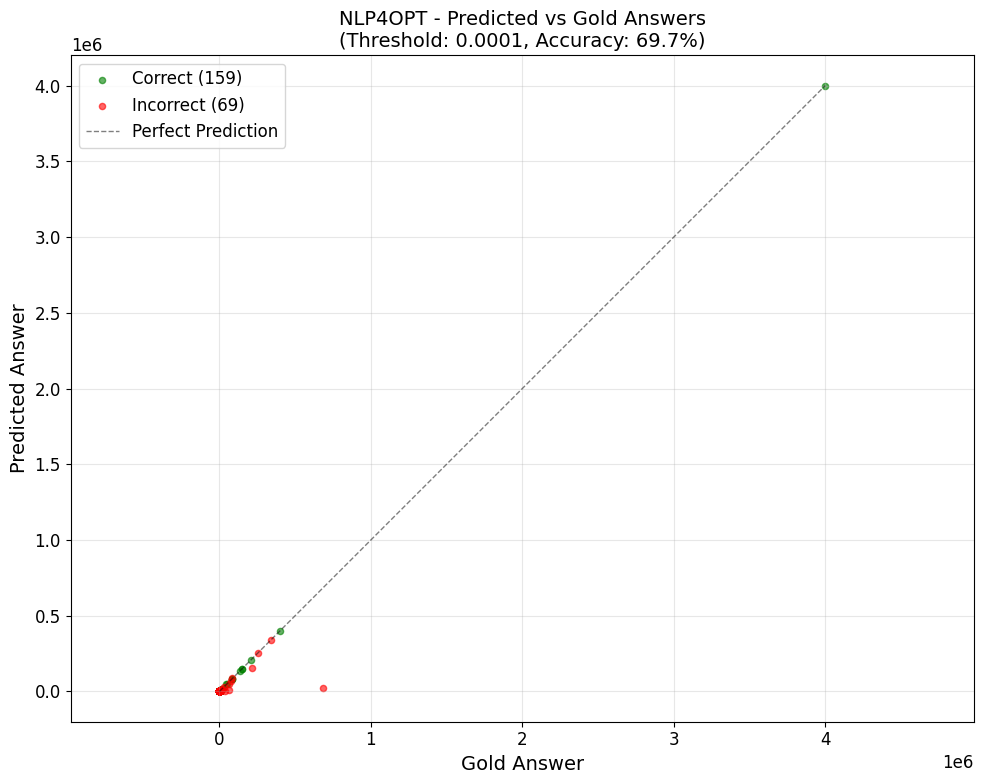


Predictions scatter plot for NLP4LP:


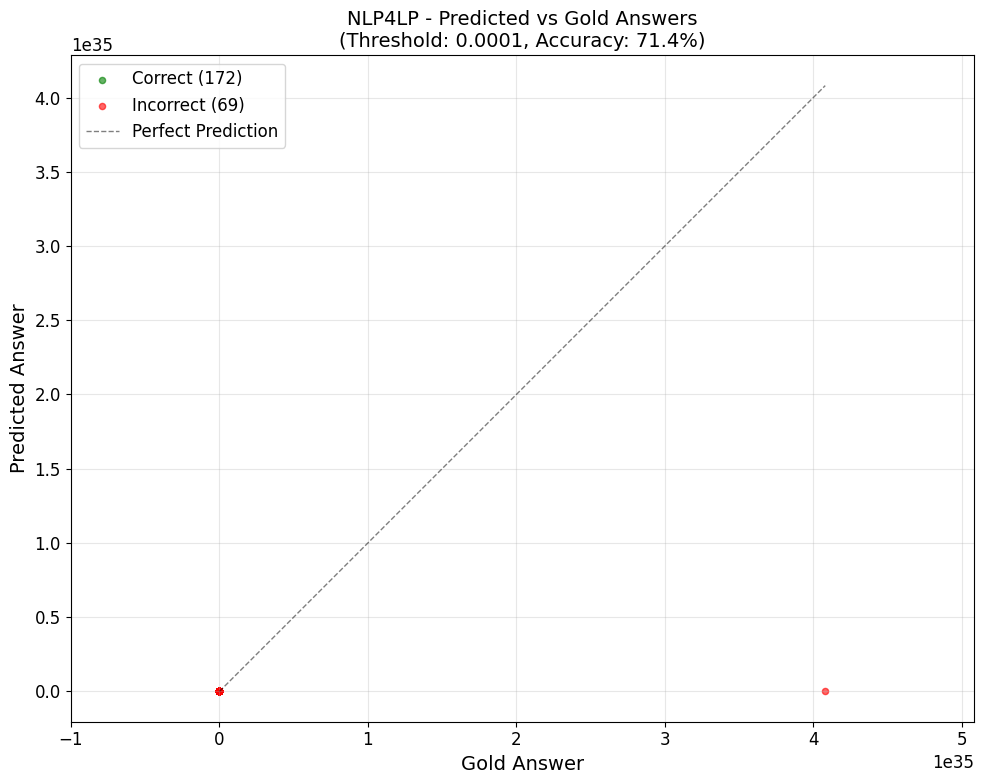

In [19]:
def plot_predictions_scatter(dataset_name, results, threshold_idx=2):
    """Plot predicted vs gold answers with correctness indicated by color."""
    result = results[threshold_idx]  # Use specified threshold index
    
    # Ensure data is in proper format for plotting
    gold_answers = np.array([float(r['gold_answer']) for r in result['detailed_results']])
    predicted_answers = np.array([float(r['predicted_answer']) for r in result['detailed_results']])
    correct_flags = [bool(r['is_correct']) for r in result['detailed_results']]
    
    correct_gold = np.array([g for g, c in zip(gold_answers, correct_flags) if c])
    correct_pred = np.array([p for p, c in zip(predicted_answers, correct_flags) if c])
    incorrect_gold = np.array([g for g, c in zip(gold_answers, correct_flags) if not c])
    incorrect_pred = np.array([p for p, c in zip(predicted_answers, correct_flags) if not c])
    
    plt.figure(figsize=(10, 8))
    
    # Plot correct predictions
    if len(correct_gold) > 0:
        plt.scatter(correct_gold, correct_pred, c='green', alpha=0.6, s=20, 
                    label=f'Correct ({len(correct_gold)})')
    
    # Plot incorrect predictions
    if len(incorrect_gold) > 0:
        plt.scatter(incorrect_gold, incorrect_pred, c='red', alpha=0.6, s=20,
                    label=f'Incorrect ({len(incorrect_gold)})')
    
    # Plot perfect prediction line
    if len(gold_answers) > 0 and len(predicted_answers) > 0:
        min_val = float(min(np.min(gold_answers), np.min(predicted_answers)))
        max_val = float(max(np.max(gold_answers), np.max(predicted_answers)))
        plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=1,
                 label='Perfect Prediction')
    
    plt.xlabel('Gold Answer', fontsize=14)
    plt.ylabel('Predicted Answer', fontsize=14)
    plt.title(f'{dataset_name} - Predicted vs Gold Answers\n'
              f'(Threshold: {result["threshold"]}, Accuracy: {result["accuracy_percentage"]:.1f}%)',
              fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Equal aspect ratio for better visualization
    plt.axis('equal')
    
    plt.tight_layout()
    plt.show()

# Create scatter plots for each dataset
for dataset_name, results in all_results.items():
    print(f"\nPredictions scatter plot for {dataset_name}:")
    plot_predictions_scatter(dataset_name, results)
